# Ways to Measure an Annual Return
### (+ annualised risk and a comparison chart)

Take daily stock prices and turn them into an **annual return** — but in **four
different flavours**, add **annualised risk**, and draw the important distinction
between two ways of averaging.

**The four return methods** (all *annualised*, i.e. expressed "per year"):

| | Method | Formula | Note |
|---|---|---|---|
| **M1** | Point-to-point (real, compounded) | `(last_price / first_price) - 1` | The actual return of buying in Jan and selling in Dec. |
| **M2** | Mean **simple** daily return × 252 | mean of `(today/yesterday - 1)`, ×252 | A common shortcut. Slightly **overstates** the truth (ignores compounding). |
| **M3** | Mean **log** daily return × 252 | mean of `ln(today/yesterday)`, ×252 | A continuously-compounded rate. Cleaner maths than M2. |
| **M4** | M3 converted back to a normal % | `exp(M3) - 1` | Puts M3 on the same scale as M1/M2 for a like-for-like comparison. |

**The averaging distinction (global vs year-by-year).** When we average daily
returns for M2/M3, over *what window*?

- **Global** — average **all** daily returns across the whole 5-year sample, then
  ×252 → **one number per stock**. *"What's this stock's typical annual return?"*
- **Year-by-year** — average only the daily returns **within one calendar year**,
  then ×252 → **one number per stock per year**. *"What did it do in 2023 specifically?"*

We compute **both** and place them side by side.

**Risk.** Annualised risk = (standard deviation of daily returns) × √252.
Volatility scales with the **square root** of time, which is why risk uses **√252**
while returns use plain **252**.

> **Note on running this notebook:** the first cell downloads live prices from Yahoo
> Finance via `yfinance`, so you need an internet connection. Each run pulls the most
> recent 5 years, so your exact numbers will differ from any earlier run.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## 1 · Setup and download

Pick the tickers and the date window (the last 5 whole years), then download the
**adjusted close** price for each. Adjusted close accounts for dividends and splits,
so returns computed from it are apples-to-apples over time.

In [2]:
tickers = ['SPY', 'NVDA', 'AIR.PA', 'MSFT', 'BA', 'JPM',
           'XOM', 'DGE.L', 'ANF', 'DPZ', 'SAP.DE']

end_date = pd.Timestamp.today().normalize()
start_date = pd.Timestamp(year=end_date.year - 5, month=1, day=1)

print(f"Downloading prices from {start_date.date()} to {end_date.date()} ...")
adj_close_df = yf.download(tickers,
                           start=start_date,
                           end=end_date,
                           auto_adjust=False)['Adj Close']

adj_close_df.tail()

[*********************100%***********************]  11 of 11 completed


Ticker,AIR.PA,ANF,BA,DGE.L,DPZ,JPM,MSFT,NVDA,SAP.DE,SPY,XOM
Date,,,,,,,,,,,
2026-08-25,204.550003,108.900002,211.080002,1735.5,349.910004,356.690002,491.709991,213.050003,185.460007,765.909973,160.639999
2026-08-26,205.850006,147.750000,212.089996,1736.5,344.559998,356.500000,496.369995,209.660004,180.020004,766.080017,158.190002
2026-08-27,203.399994,145.750000,209.889999,1701.5,332.059998,354.220001,505.059998,227.979996,189.880005,771.099976,156.440002
2026-08-28,203.050003,148.419998,209.820007,1709.0,350.000000,357.619995,513.530029,217.550003,191.320007,769.349976,156.710007
2026-08-31,197.240005,143.080002,207.779999,NaN,342.059998,356.019989,507.290009,220.779999,190.899994,767.049988,160.949997


## 2 · Reshape to long (tidy) format and compute daily returns

The download gives a **wide** table (one column per ticker). We reshape it to
**long/tidy** format — one row per (date, ticker) — because it makes grouped
calculations and seaborn plotting much easier.

- `.melt()` stacks the ticker columns into a single `Ticker` column plus a `Adj_Close` value column.
- `.groupby('Ticker')` keeps each stock's calculation separate (so we never compute a
  return across two different companies).
- **Simple return** = `(today / yesterday) - 1`, via `.pct_change()`.
- **Log return** = `ln(today / yesterday)`.

In [3]:
long_df = (adj_close_df
           .reset_index()
           .melt(id_vars='Date', var_name='Ticker', value_name='Adj_Close')
           .dropna()
           .sort_values(['Ticker', 'Date'])
           .reset_index(drop=True))

long_df['Year'] = long_df['Date'].dt.year

# Simple daily return: (today / yesterday) - 1
long_df['Simple_Return'] = long_df.groupby('Ticker')['Adj_Close'].pct_change()
# Log daily return: ln(today / yesterday)
long_df['Log_Return'] = (long_df.groupby('Ticker')['Adj_Close']
                         .transform(lambda p: np.log(p / p.shift(1))))

TRADING_DAYS = 252

long_df.head()

,Date,Ticker,Adj_Close,Year,Simple_Return,Log_Return
0,2021-01-04,AIR.PA,82.468239,2021,NaN,NaN
1,2021-01-05,AIR.PA,82.413193,2021,-0.000667,-0.000668
2,2021-01-06,AIR.PA,82.725121,2021,0.003785,0.003778
3,2021-01-07,AIR.PA,82.220535,2021,-0.006100,-0.006118
4,2021-01-08,AIR.PA,82.660904,2021,0.005356,0.005342


## 3 · Global metrics — one number per stock (all years at once)

Group by **ticker only**, so every average spans the entire sample. Everything
ending in `_global` uses the whole 5 years.

In [ ]:
global_metrics = (long_df.groupby('Ticker')
                  .agg(mean_simple=('Simple_Return', 'mean'),
                       mean_log=('Log_Return', 'mean'),
                       std_log=('Log_Return', 'std'),      # risk from LOG returns
                       first_px=('Adj_Close', 'first'),
                       last_px=('Adj_Close', 'last'),
                       n_days=('Simple_Return', 'count'))
                  .reset_index())

# Annualise
global_metrics['M2_global'] = global_metrics['mean_simple'] * TRADING_DAYS
global_metrics['M3_global'] = global_metrics['mean_log'] * TRADING_DAYS
global_metrics['M4_global'] = np.exp(global_metrics['M3_global']) - 1   # M3 -> simple

# Risk uses LOG returns: log returns add across time, which is exactly the
# assumption behind the sqrt(252) scaling (and it matches M3). For daily data
# the number is virtually identical to using simple returns.
global_metrics['Risk_global'] = global_metrics['std_log'] * np.sqrt(TRADING_DAYS)

# A "true" whole-sample M1: the compound annual growth rate (CAGR), annualised.
global_metrics['M1_global_CAGR'] = (
    (global_metrics['last_px'] / global_metrics['first_px'])
)

global_metrics.round(4)

,Ticker,mean_simple,mean_log,std_log,first_px,last_px,n_days,M2_global,M3_global,M4_global,Risk_global,M1_global_CAGR
0,AIR.PA,0.0008,0.0006,0.0184,82.4682,197.24,1449,0.1941,0.1517,0.1638,0.2915,0.1638
1,ANF,0.0021,0.0014,0.0383,20.4900,143.08,1420,0.5313,0.3449,0.4118,0.6075,0.4118
2,BA,0.0003,0.0000,0.0230,202.7200,207.78,1420,0.0711,0.0044,0.0044,0.3654,0.0044
3,DGE.L,-0.0003,-0.0004,0.0147,2943.5703,1709.00,1426,-0.0688,-0.0961,-0.0916,0.2340,-0.0916
4,DPZ,0.0002,-0.0000,0.0187,352.2441,342.06,1420,0.0386,-0.0052,-0.0052,0.2962,-0.0052
5,JPM,0.0009,0.0008,0.0152,109.0005,356.02,1420,0.2392,0.2101,0.2337,0.2410,0.2337
6,MSFT,0.0008,0.0006,0.0172,207.5654,507.29,1420,0.1958,0.1586,0.1719,0.2725,0.1719
7,NVDA,0.0025,0.0020,0.0318,13.0608,220.78,1420,0.6304,0.5018,0.6517,0.5051,0.6517
8,SAP.DE,0.0006,0.0005,0.0176,95.3912,190.90,1442,0.1603,0.1212,0.1289,0.2796,0.1289
9,SPY,0.0006,0.0006,0.0105,342.4370,767.05,1420,0.1571,0.1431,0.1539,0.1670,0.1539


## 4 · Year-by-year metrics — one number per stock *per year*

Same calculations, but group by **both** `Year` and `Ticker`, so each average is
taken **within a single calendar year**.

In [5]:
yearly = (long_df.groupby(['Year', 'Ticker'])
          .agg(mean_simple=('Simple_Return', 'mean'),
               mean_log=('Log_Return', 'mean'),
               std_log=('Log_Return', 'std'),        # risk from LOG returns
               first_px=('Adj_Close', 'first'),
               last_px=('Adj_Close', 'last'),
               Days=('Simple_Return', 'count'))
          .reset_index())

# M1: the real point-to-point return for that year (first vs last price).
yearly['M1_point_to_point'] = yearly['last_px'] / yearly['first_px'] - 1
# M2 / M3 / M4: the shortcuts, but averaged WITHIN the year only.
yearly['M2_yearly'] = yearly['mean_simple'] * TRADING_DAYS
yearly['M3_yearly'] = yearly['mean_log'] * TRADING_DAYS
yearly['M4_yearly'] = np.exp(yearly['M3_yearly']) - 1
# Annualised risk for that single year, from LOG returns.
yearly['Risk_yearly'] = yearly['std_log'] * np.sqrt(TRADING_DAYS)

yearly.head()

,Year,Ticker,mean_simple,mean_log,std_log,first_px,last_px,Days,M1_point_to_point,M2_yearly,M3_yearly,M4_yearly,Risk_yearly
0,2021,AIR.PA,0.001082,0.000868,0.020725,82.468239,103.083008,257,0.249972,0.272693,0.218780,0.244558,0.328998
1,2021,ANF,0.002659,0.002114,0.033060,20.490000,34.830002,251,0.699854,0.670043,0.532656,0.703450,0.524816
2,2021,BA,0.000221,-0.000028,0.022291,202.720001,201.320007,251,-0.006906,0.055642,-0.006958,-0.006933,0.353863
3,2021,DGE.L,0.001301,0.001247,0.010266,2943.570312,4030.828369,252,0.369367,0.327788,0.314349,0.369367,0.162974
4,2021,DPZ,0.001741,0.001614,0.015780,352.244110,528.162720,251,0.499422,0.438706,0.406694,0.501844,0.250501


## 5 · Combine — put each year next to the stock's global average

Merge the whole-sample columns onto every yearly row, so each line shows
this year beside the stock's long-run average.

In [6]:
comparison = yearly.merge(
    global_metrics[['Ticker', 'M2_global', 'M3_global', 'Risk_global']],
    on='Ticker', how='left'
)

# Choose and order the columns we actually want to see.
cols = ['Year', 'Ticker', 'Days',
        'M1_point_to_point',                      # real return, this year
        'M2_yearly', 'M3_yearly', 'M4_yearly',    # shortcuts, this year
        'Risk_yearly',                            # risk, this year
        'M2_global', 'M3_global',                 # long-run average shortcuts
        'Risk_global']                            # long-run average risk
comparison = comparison[cols]
comparison.head()

,Year,Ticker,Days,M1_point_to_point,M2_yearly,M3_yearly,M4_yearly,Risk_yearly,M2_global,M3_global,Risk_global
0,2021,AIR.PA,257,0.249972,0.272693,0.218780,0.244558,0.328998,0.194115,0.151654,0.291480
1,2021,ANF,251,0.699854,0.670043,0.532656,0.703450,0.524816,0.531250,0.344897,0.607462
2,2021,BA,251,-0.006906,0.055642,-0.006958,-0.006933,0.353863,0.071083,0.004375,0.365391
3,2021,DGE.L,252,0.369367,0.327788,0.314349,0.369367,0.162974,-0.068846,-0.096084,0.233972
4,2021,DPZ,251,0.499422,0.438706,0.406694,0.501844,0.250501,0.038608,-0.005207,0.296201


## 6 · Show the tables

We format everything as a percentage per year for readability.

In [7]:
pd.set_option('display.width', 220)
pd.set_option('display.max_rows', 300)
pd.set_option('display.float_format', lambda x: f'{x*100:6.2f}%')

print("=== YEAR-BY-YEAR vs GLOBAL (returns & risk as % per year) ===")
print(comparison.to_string(index=False))

print("\n=== GLOBAL (whole-sample) summary, one row per stock ===")
gshow = global_metrics[['Ticker', 'M1_global_CAGR', 'M2_global',
                        'M3_global', 'M4_global', 'Risk_global']]
print(gshow.to_string(index=False))

=== YEAR-BY-YEAR vs GLOBAL (returns & risk as % per year) ===
 Year Ticker  Days  M1_point_to_point  M2_yearly  M3_yearly  M4_yearly  Risk_yearly  M2_global  M3_global  Risk_global
 2021 AIR.PA   257             25.00%     27.27%     21.88%     24.46%       32.90%     19.41%     15.17%       29.15%
 2021    ANF   251             69.99%     67.00%     53.27%     70.35%       52.48%     53.13%     34.49%       60.75%
 2021     BA   251             -0.69%      5.56%     -0.70%     -0.69%       35.39%      7.11%      0.44%       36.54%
 2021  DGE.L   252             36.94%     32.78%     31.43%     36.94%       16.30%     -6.88%     -9.61%       23.40%
 2021    DPZ   251             49.94%     43.87%     40.67%     50.18%       25.05%      3.86%     -0.52%       29.62%
 2021    JPM   251             28.96%     27.82%     25.54%     29.09%       21.35%     23.92%     21.01%       24.10%
 2021   MSFT   251             55.79%     46.74%     44.51%     56.07%       20.93%     19.58%     15.86%

## 7 · Compare the four return methods (whole-sample)

We chart the **global** numbers because that's one clean value per stock per method
(charting all 55 year×stock combinations would be unreadable). We reshape to long
format so seaborn can put the four methods side by side for each stock.

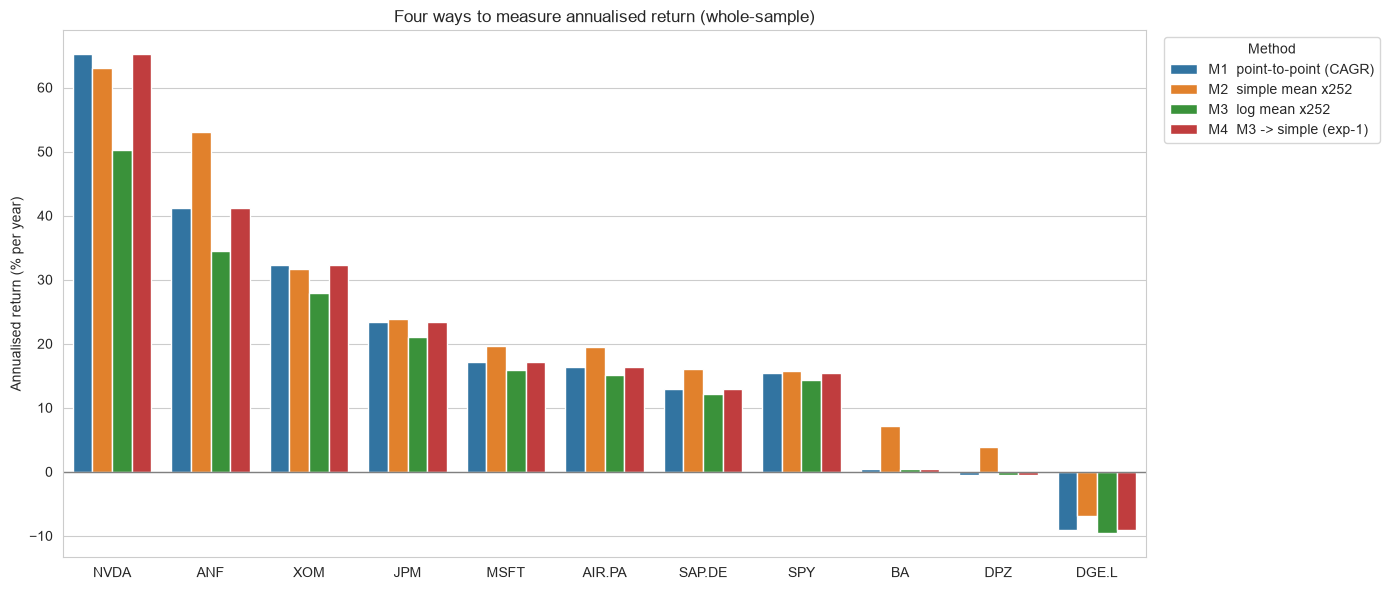

In [8]:
sns.set_style("whitegrid")

# Left-to-right stock order (highest M2 first) so the chart is easy to scan.
ticker_order = (global_metrics.sort_values('M2_global', ascending=False)['Ticker']
                .tolist())

# --- Reshape to LONG format for seaborn: one row per (stock, method) ---
method_names = {
    'M1_global_CAGR': 'M1  point-to-point (CAGR)',
    'M2_global':      'M2  simple mean x252',
    'M3_global':      'M3  log mean x252',
    'M4_global':      'M4  M3 -> simple (exp-1)',
}
returns_long = (global_metrics
                .melt(id_vars='Ticker',
                      value_vars=list(method_names),     # the four method columns
                      var_name='Method',
                      value_name='Return'))
returns_long['Return'] *= 100                            # to percent
returns_long['Method'] = returns_long['Method'].map(method_names)   # nice labels

# --- Draw the grouped bar chart ---
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=returns_long, x='Ticker', y='Return',
                 hue='Method', order=ticker_order)
ax.axhline(0, color='gray', lw=1)
ax.set_title('Four ways to measure annualised return (whole-sample)')
ax.set_xlabel('')
ax.set_ylabel('Annualised return (% per year)')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8 · Risk–return chart, year by year

One small scatter per calendar year: **risk on the x-axis, return on the y-axis**,
each point a stock. Both metrics come from **log** daily returns:

- `Annual_Return = exp(mean(log return) × 252) - 1`  (annualise, then convert back to a normal %, i.e. M4)
- `Annual_Risk   = std(log return) × √252`

In [9]:
annual_metrics = yearly.assign(
    Annual_Return=np.exp(yearly['mean_log'] * TRADING_DAYS) - 1,
    Annual_Risk=yearly['std_log'] * np.sqrt(TRADING_DAYS),
)

print("--- Annual Risk-Return Metrics (Tidy Format) ---")
print(annual_metrics[['Year', 'Ticker', 'Annual_Return', 'Annual_Risk']]
      .head(10).to_string())

--- Annual Risk-Return Metrics (Tidy Format) ---
   Year  Ticker  Annual_Return  Annual_Risk
0  2021  AIR.PA         24.46%       32.90%
1  2021     ANF         70.35%       52.48%
2  2021      BA         -0.69%       35.39%
3  2021   DGE.L         36.94%       16.30%
4  2021     DPZ         50.18%       25.05%
5  2021     JPM         29.09%       21.35%
6  2021    MSFT         56.07%       20.93%
7  2021    NVDA        125.20%       44.77%
8  2021  SAP.DE         20.40%       21.19%
9  2021     SPY         30.64%       12.94%


Generating plot...
Saved chart to 'risk_return_by_year.png'


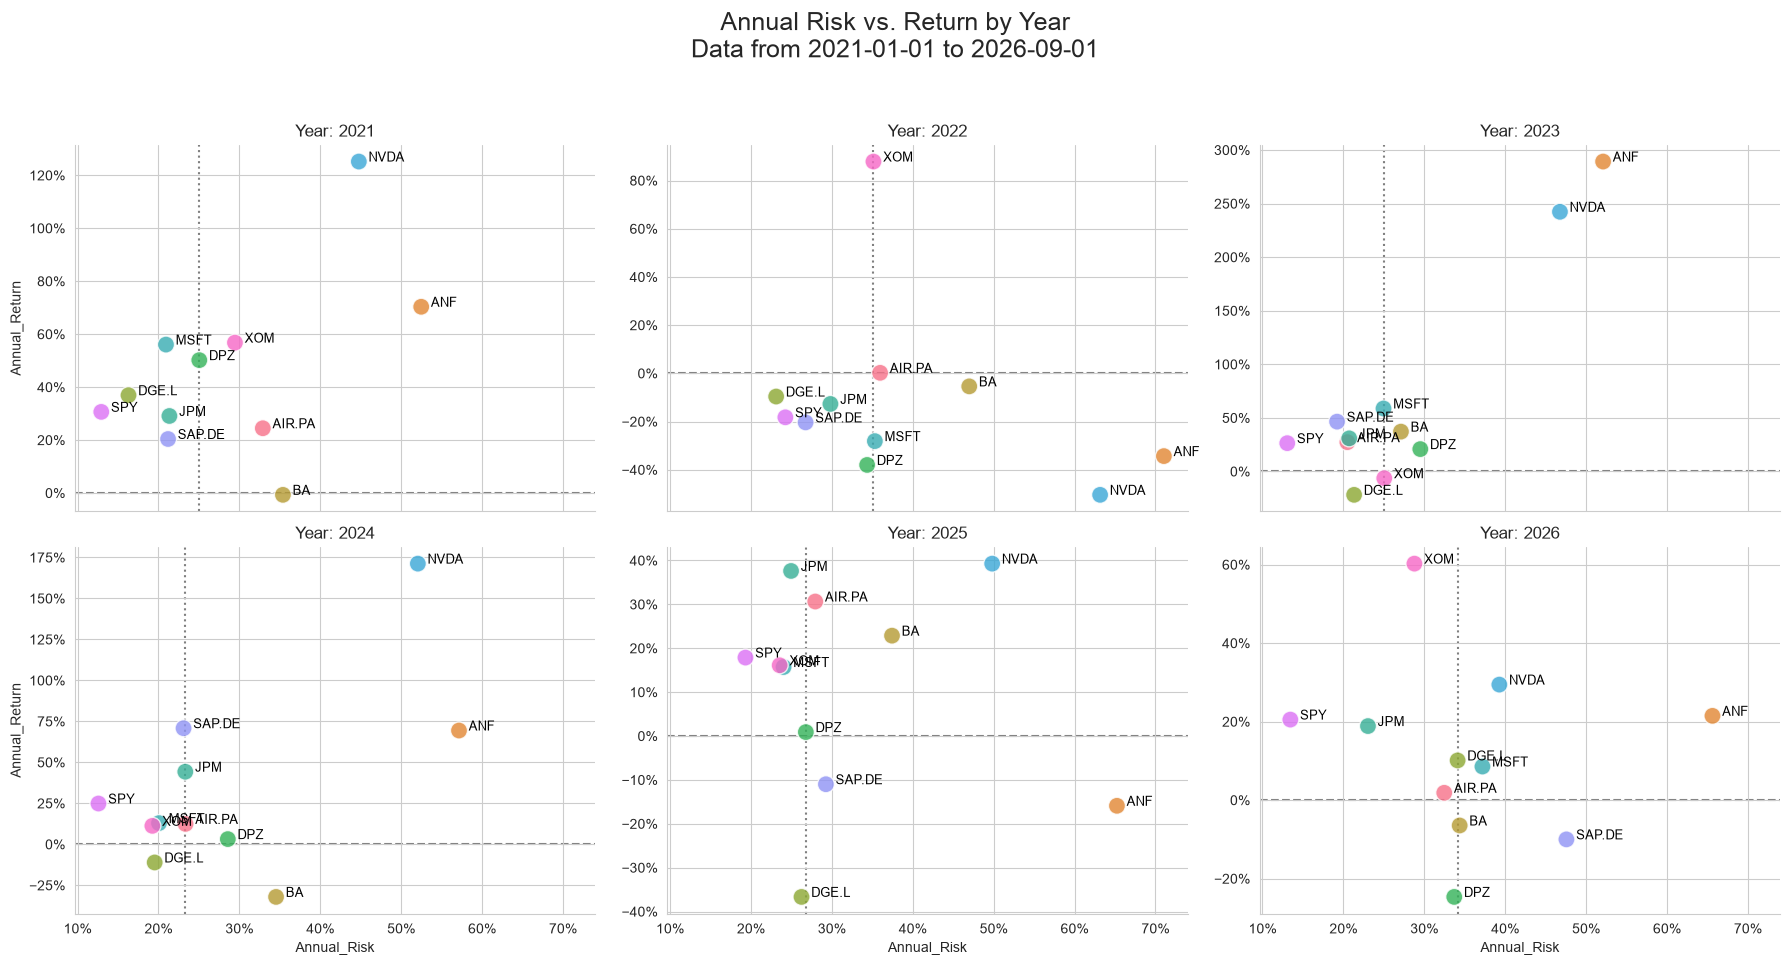

In [10]:
print("Generating plot...")
g = sns.relplot(
    data=annual_metrics,
    x='Annual_Risk',
    y='Annual_Return',
    hue='Ticker',
    col='Year',
    col_wrap=3,
    s=150,
    alpha=0.8,
    height=5,
    aspect=1.2,
    kind='scatter',
    legend=False,
    facet_kws={'sharey': False}   # let each year's panel auto-scale its own y-axis
)

for year, ax in g.axes_dict.items():
    ax.set_title(f"Year: {year}")
    year_data = annual_metrics[annual_metrics['Year'] == year]

    # Direct text label next to each point
    for idx, row in year_data.iterrows():
        ax.annotate(
            text=row['Ticker'],
            xy=(row['Annual_Risk'], row['Annual_Return']),
            color='black',
            size=9,
            weight='normal',
            xytext=(7, 0),
            textcoords='offset points'
        )

    # Percent-format the axes and add reference lines
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
    ax.axhline(0, ls='--', color='gray', zorder=0)

    if not year_data.empty:
        median_risk = year_data['Annual_Risk'].median()
        ax.axvline(median_risk, ls=':', color='gray', zorder=0, label='Median Risk')

title_str = (f"Annual Risk vs. Return by Year\n"
             f"Data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
g.fig.suptitle(title_str, fontsize=18)
g.fig.tight_layout(rect=[0, 0.02, 1, 0.95])

g.savefig('risk_return_by_year.png', dpi=150, bbox_inches='tight')
print("Saved chart to 'risk_return_by_year.png'")
plt.show()

## 9 · Save the full table for Excel

In [11]:
comparison.to_csv('three_annual_returns.csv', index=False)
print("Saved table to 'three_annual_returns.csv'")

Saved table to 'three_annual_returns.csv'
